<a href="https://colab.research.google.com/github/mohammedaslanshas/codomax-ds-internship/blob/main/Day11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Cleaning (from Day 7)
df = df.drop(columns=["Cabin"])
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop_duplicates()
df = df.reset_index(drop=True)

# Organizing (from Day 7)
df = df[["Name", "Age", "Sex", "Pclass", "Survived", "Fare", "Embarked"]]
df = df.rename(columns={"Sex": "Gender", "Pclass": "Ticketclass"})
df["Ticketclass"] = df["Ticketclass"].astype("category")
df["Survived"] = df["Survived"].astype(bool)

# Verify it matches Day 7/8's final state before moving on
print(df.shape)          # should be (891, 7)
print(df.isnull().sum()) # should be all 0
df.info()

(891, 7)
Name           0
Age            0
Gender         0
Ticketclass    0
Survived       0
Fare           0
Embarked       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Name         891 non-null    object  
 1   Age          891 non-null    float64 
 2   Gender       891 non-null    object  
 3   Ticketclass  891 non-null    category
 4   Survived     891 non-null    bool    
 5   Fare         891 non-null    float64 
 6   Embarked     891 non-null    object  
dtypes: bool(1), category(1), float64(2), object(3)
memory usage: 36.8+ KB
(891, 7)
Name           0
Age            0
Gender         0
Ticketclass    0
Survived       0
Fare           0
Embarked       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype   
---  

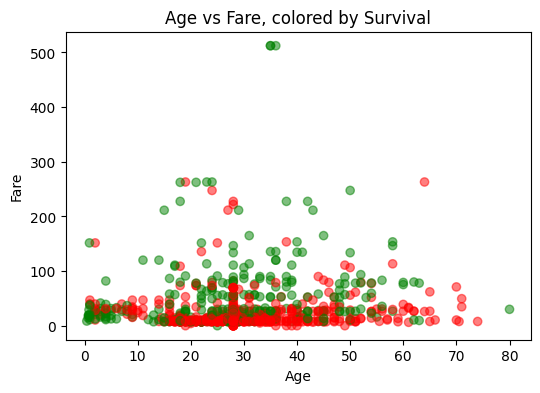

In [3]:

colors = df["Survived"].map({True: "green", False: "red"})

plt.figure(figsize=(6,4))
plt.scatter(df["Age"], df["Fare"], c=colors, alpha=0.5)
plt.title("Age vs Fare, colored by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

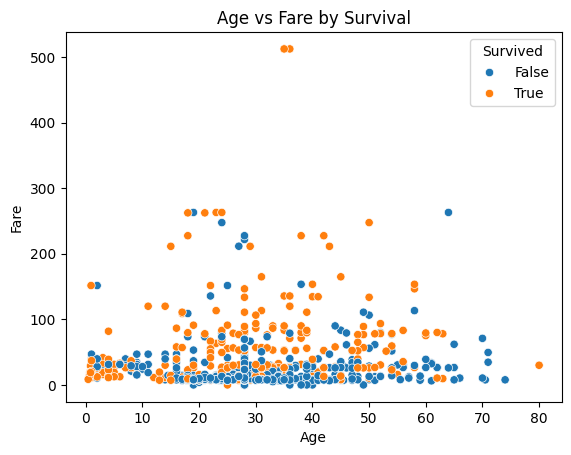

In [4]:
import seaborn as sns

sns.scatterplot(data=df, x="Age", y="Fare", hue="Survived")
plt.title("Age vs Fare by Survival")
plt.show()

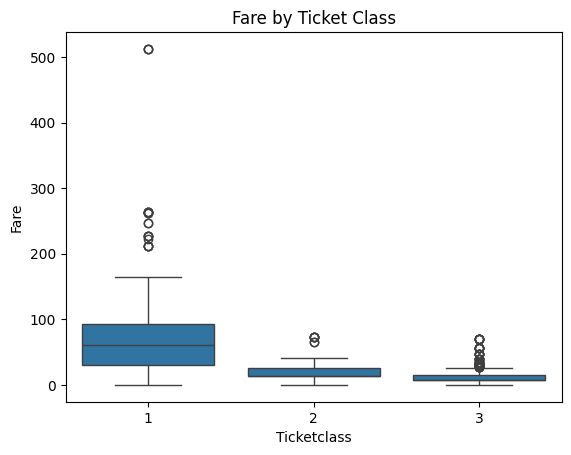

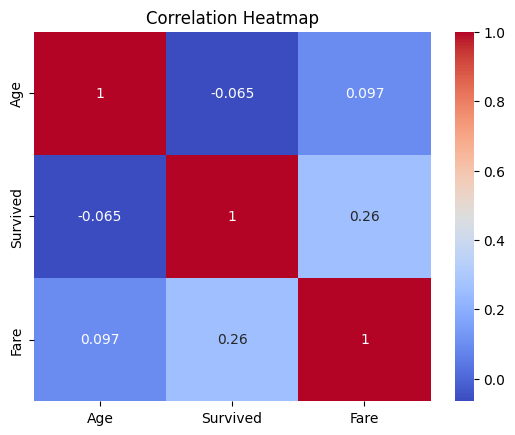

In [5]:

# Boxplot by category — cleaner than Matplotlib's version
sns.boxplot(data=df, x="Ticketclass", y="Fare")
plt.title("Fare by Ticket Class")
plt.show()

# Correlation heatmap — visualizes Day 8's correlation matrix
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

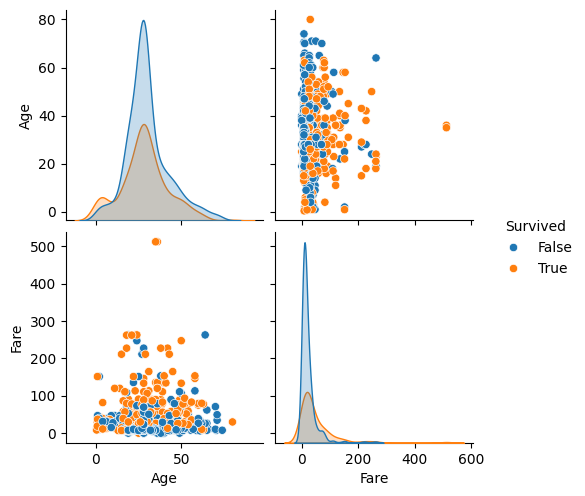

In [6]:
sns.pairplot(df[["Age", "Fare", "Survived"]], hue="Survived")
plt.show()